In [1]:
from dataclasses import replace
import numpy as np

from sim.camera import Camera
from sim.lens import Lens
from sim.frame import make_blank_frame, display_frame
from sim.mask import Mask
from sim.render import RenderConfig, render, plot_render_stages
from sim.physics.stars import load_star_field  # only if you want the on-sensor count
from sim.frame import plot_star_rois
from sim.frame import save_frame_fits

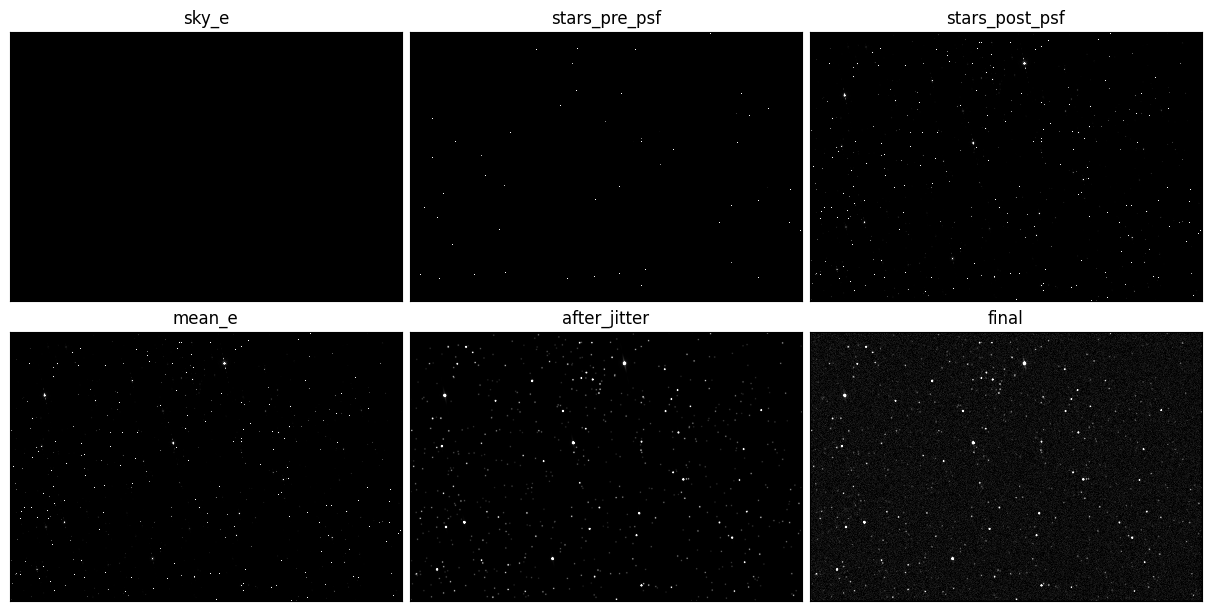

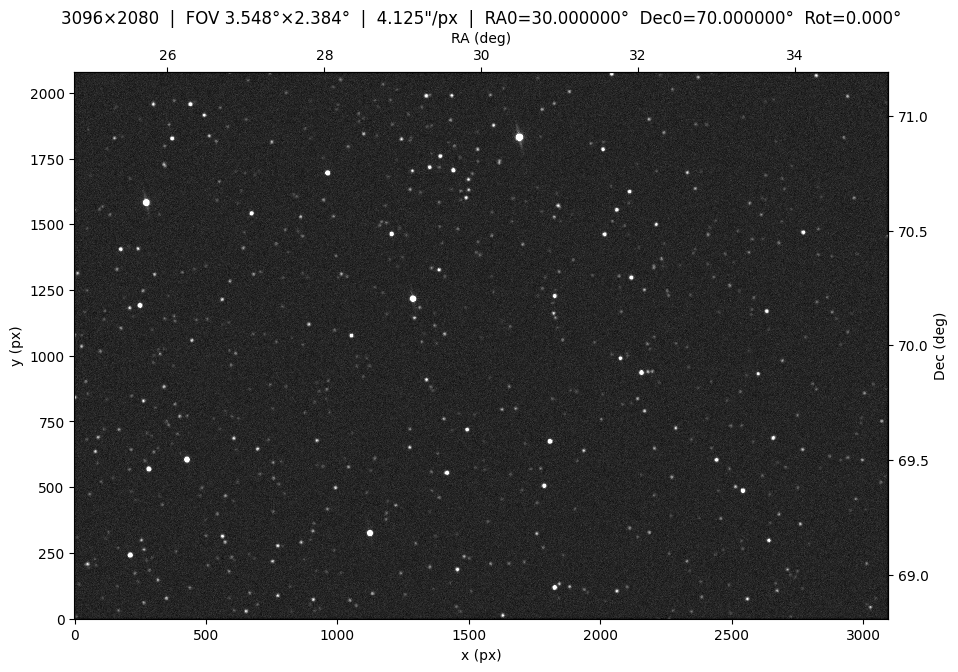

In [24]:
# ===============================
# Drone-payload-like setup (small planetary cam + fast wide lens + simple spider)
# ===============================

STAR_CSV = "sim/physics/starfields/field2.csv"

# Pointing
RA0_DEG  = 30.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

# -------------------------------
# Camera: ZWO ASI178/ASI187-ish class
# (small sensor, small pixels, relatively low read noise)
# -------------------------------
cam = Camera(
    nx=3096,            # ASI178: 3096x2080 (if you're actually using ASI187, swap dims)
    ny=2080,
    pixel_um=2.4,       # ASI178 is 2.4um; good stand-in for "small planetary cam"
    read_noise_e=2.0,   # depends on gain; 1.5–3 e- is plausible
    gain_e_per_adu=1.0,
    qe=0.6,
)

# -------------------------------
# Lens: small C-mount / machine-vision style lens
# Wide-ish FOV, fast-ish (so stars show up)
# Example: 12 mm f/1.8
# -------------------------------
lens = Lens(
    focal_mm=120.0,
    f_number=1.8,
    transmission=0.9,
)

frame = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)

# -------------------------------
# Mask: simple spider vanes across a *small* entrance pupil
# Use POPPY "SecondaryObscuration" supports with:
#  - a circular aperture set by the lens entrance pupil diameter
#  - no secondary obstruction (obstruction_frac=0)
#
# Entrance pupil diameter ~ f / f#
# For f=12mm, f/1.8 => D ~ 6.7 mm
# -------------------------------
mask = Mask(
    kind="poppy",
    aperture_diam_mm= lens.focal_mm / lens.f_number, 
    obstruction_frac=0.0,          # camera lens: no central secondary
    vane_width_mm=0.6,            # thin vanes (try 0.05–0.3 mm)
    n_vanes=2,                     # n_vanes counts unique lines over 180deg => 2 gives a "+" cross
    angle_deg=12.0,                 # rotate spider pattern if desired
    psf_size_px=300,               # keep modest; increase if you want longer spikes
)

# -------------------------------
# Render config
# -------------------------------
cfg = RenderConfig(
    exposure_s=10.0,                # drone payload likely short exposures
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,         # keep your existing "derived" behavior for now
    lambda_eff_nm=550.0,
    band_nm=90.0,

    # Optional extra blur (focus/aberrations/seeing). For a tiny lens, keep small.
    psf_sigma_px=0.6,              # try 0.3–1.2

    mask=mask,
    jitter_pointing_rms = 16,

    enable_sky=True,
    enable_stars=True,
    enable_psf=True,
    enable_jitter=True,
    enable_noise=True,

    seed=42,
)

frame2, res2 = render(frame, cfg, stars=STAR_CSV)

plot_render_stages(frame2, res2, cmap="gray", stretch="asinh", shared_scale=True)

# A nice final view
display_frame(frame2, cmap="gray", stretch="asinh", q_lo=0, q_hi=99.9)

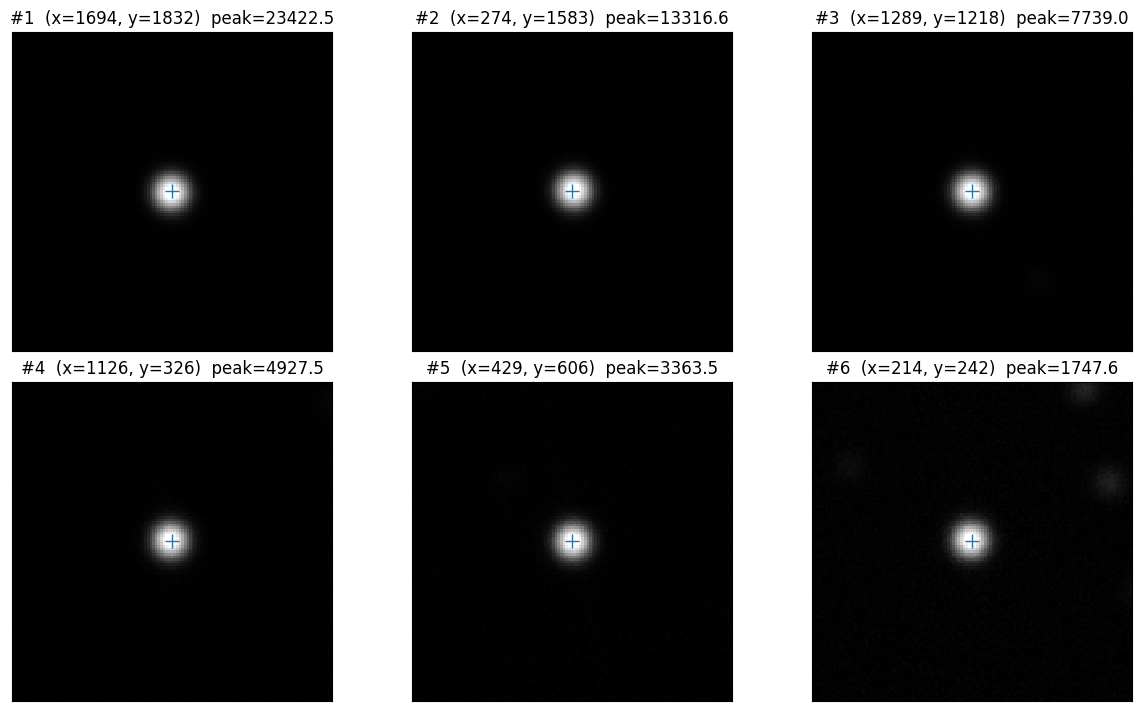

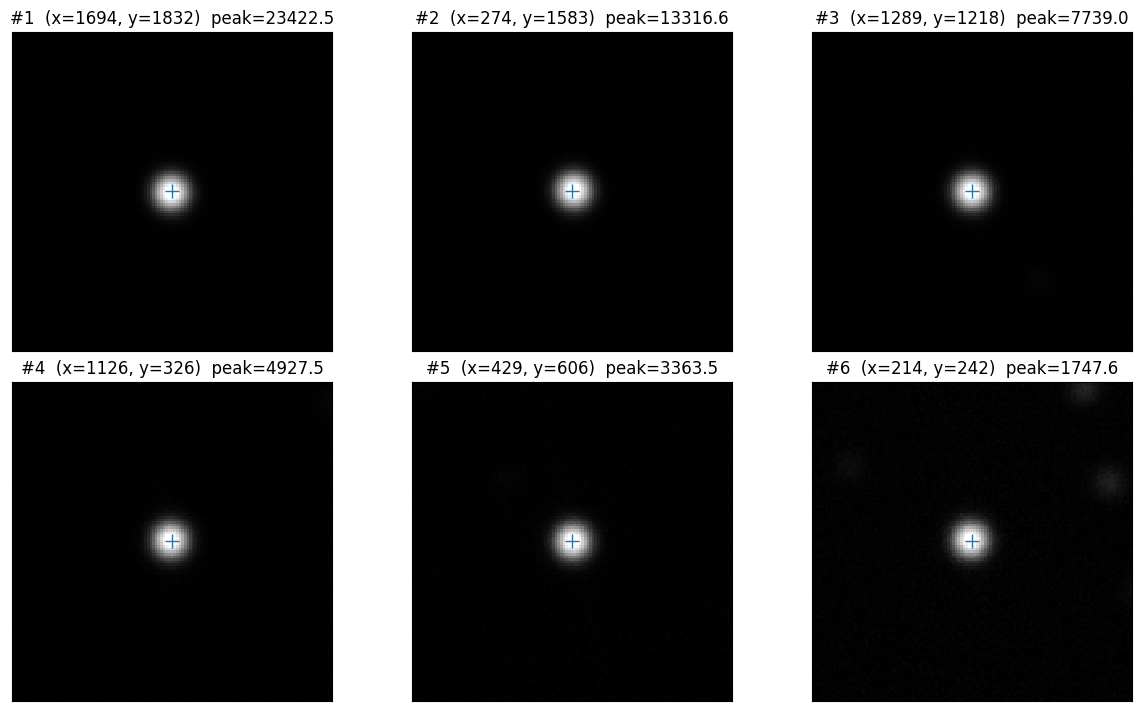

In [29]:
plot_star_rois(frame, image=res2.final_e,
               n=6, half_size=60, min_sep_px=30,
               stretch="log", cmap="gray")

In [19]:
out = save_frame_fits(
    "out/newt_asi1600_final_e5.fits",
    frame,
    cfg=cfg,
    res=res2,
    stage="final_e",
    stars_csv=STAR_CSV,
    overwrite=True,
)
print("Wrote:", out)

Wrote: out\newt_asi1600_final_e5.fits
